In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc, RocCurveDisplay
)

In [2]:
# Load the dataset
df = pd.read_csv("../../results/outputs/final_preprocessed_telco_data_new.csv")

In [3]:
display(df.head())
# Define features & target
X = df.drop("Churn", axis=1)
y = df["Churn"]

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Churn
0,-2.839944,-1.247643,1.014425,-0.339953,-1.099294,0.092576,0.517341,0.408477,-0.086671,-0.036771,0
1,-0.352317,1.434602,-0.451466,-0.359328,0.000225,-0.189705,-0.298579,-0.370672,-0.114527,0.056526,0
2,-2.088348,-0.190338,-1.506188,-1.079722,-0.208352,-0.238015,0.160883,-0.210342,0.153532,0.008629,1
3,-0.375654,1.872523,-0.302458,-0.423412,-0.256734,-0.361657,-0.244218,0.374798,0.185815,0.003063,0
4,-1.362409,-2.841712,0.577507,0.012427,0.531640,0.700028,0.178311,-0.106544,0.143042,-0.114418,1


In [4]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Dictionary to store comparison results
comparison = {}

In [7]:
#Part 1 Linear Kernal SVM
param_grid_linear = {'C': [0.1, 1, 10], 'kernel': ['linear']}
svm_linear = SVC(probability=True)
grid_linear = GridSearchCV(svm_linear, param_grid_linear, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_linear.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


,estimator,SVC(probability=True)
,param_grid,"{'C': [0.1, 1, ...], 'kernel': ['linear']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1


In [8]:
best_linear = grid_linear.best_estimator_
y_pred_linear = best_linear.predict(X_test_scaled)

In [9]:
comparison['Linear SVM'] = {
    'accuracy': accuracy_score(y_test, y_pred_linear),
    'precision': precision_score(y_test, y_pred_linear),
    'recall': recall_score(y_test, y_pred_linear),
    'f1_score': f1_score(y_test, y_pred_linear),
    'best_params': grid_linear.best_params_
}

In [10]:
print(f"Best Parameters: {grid_linear.best_params_}")
print(f"Test Accuracy: {comparison['Linear SVM']['accuracy']:.4f}")
print(classification_report(y_test, y_pred_linear))

Best Parameters: {'C': 0.1, 'kernel': 'linear'}
Test Accuracy: 0.7807
              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1035
           1       0.64      0.40      0.49       374

    accuracy                           0.78      1409
   macro avg       0.72      0.66      0.68      1409
weighted avg       0.76      0.78      0.76      1409



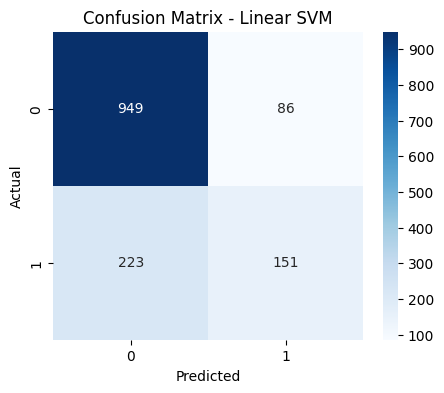

In [11]:
# Confusion Matrix
cm_linear = confusion_matrix(y_test, y_pred_linear)
plt.figure(figsize=(5,4))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

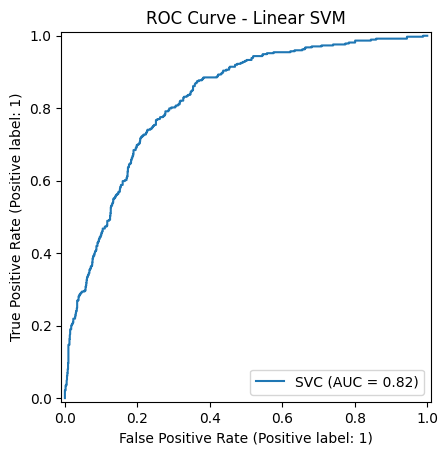

In [12]:
# ROC Curve
RocCurveDisplay.from_estimator(best_linear, X_test_scaled, y_test)
plt.title("ROC Curve - Linear SVM")
plt.show()

In [13]:
#Part 2 -RBF Kenal SVM
param_grid_rbf = {'C':[0.1,1,10], 'kernel':['rbf'], 'gamma':['scale','auto']}
svm_rbf = SVC(probability=True)
grid_rbf = GridSearchCV(svm_rbf, param_grid_rbf, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_rbf.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,estimator,SVC(probability=True)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [14]:
best_rbf = grid_rbf.best_estimator_
y_pred_rbf = best_rbf.predict(X_test_scaled)

In [15]:
comparison['RBF SVM'] = {
    'accuracy': accuracy_score(y_test, y_pred_rbf),
    'precision': precision_score(y_test, y_pred_rbf),
    'recall': recall_score(y_test, y_pred_rbf),
    'f1_score': f1_score(y_test, y_pred_rbf),
    'best_params': grid_rbf.best_params_
}

In [16]:
print(f"Best Parameters: {grid_rbf.best_params_}")
print(f"Test Accuracy: {comparison['RBF SVM']['accuracy']:.4f}")
print(classification_report(y_test, y_pred_rbf))

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Test Accuracy: 0.7935
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



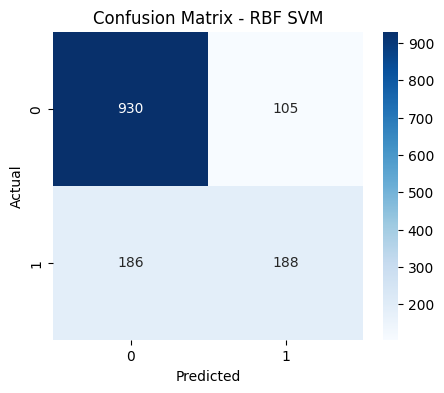

In [17]:
# Confusion Matrix
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - RBF SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

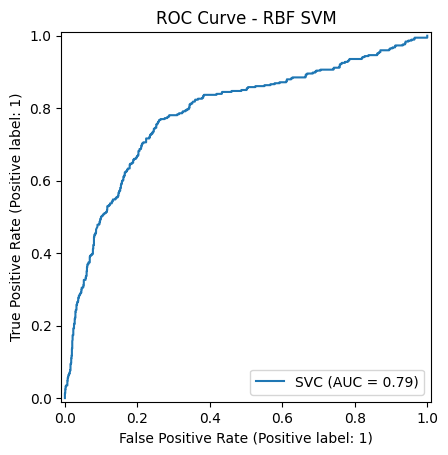

In [18]:
# ROC Curve
RocCurveDisplay.from_estimator(best_rbf, X_test_scaled, y_test)
plt.title("ROC Curve - RBF SVM")
plt.show()

In [19]:
#Part 3- Polynomial kernal SVM
param_grid_poly = {
    'C': [0.1, 1, 10],
    'kernel': ['poly'],
    'degree': [2, 3, 4],
    'gamma': ['scale', 'auto']
}

In [20]:
svm_poly = SVC(probability=True)
grid_poly = GridSearchCV(svm_poly, param_grid_poly, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_poly.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,estimator,SVC(probability=True)
,param_grid,"{'C': [0.1, 1, ...], 'degree': [2, 3, ...], 'gamma': ['scale', 'auto'], 'kernel': ['poly']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [21]:
best_poly = grid_poly.best_estimator_
y_pred_poly = best_poly.predict(X_test_scaled)

In [22]:
comparison['Polynomial SVM'] = {
    'accuracy': accuracy_score(y_test, y_pred_poly),
    'precision': precision_score(y_test, y_pred_poly),
    'recall': recall_score(y_test, y_pred_poly),
    'f1_score': f1_score(y_test, y_pred_poly),
    'best_params': grid_poly.best_params_
}

In [23]:
print(f"Best Parameters: {grid_poly.best_params_}")
print(f"Test Accuracy: {comparison['Polynomial SVM']['accuracy']:.4f}")
print(classification_report(y_test, y_pred_poly))

Best Parameters: {'C': 10, 'degree': 3, 'gamma': 'auto', 'kernel': 'poly'}
Test Accuracy: 0.7913
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



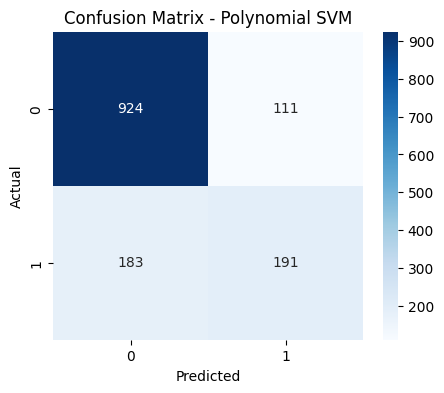

In [24]:
# Confusion Matrix
cm_poly = confusion_matrix(y_test, y_pred_poly)
plt.figure(figsize=(5,4))
sns.heatmap(cm_poly, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Polynomial SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

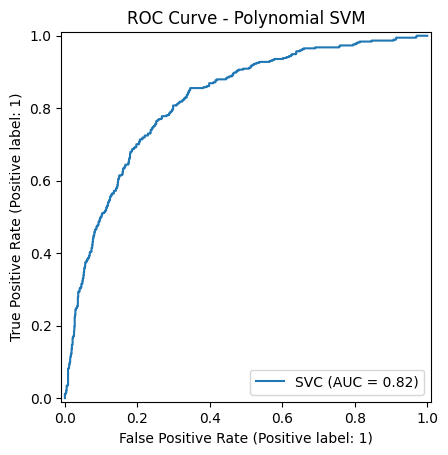

In [25]:
# ROC Curve
RocCurveDisplay.from_estimator(best_poly, X_test_scaled, y_test)
plt.title("ROC Curve - Polynomial SVM")
plt.show()

In [26]:
#Comparison of SVM Varieties
comparison_data = []
for model_name, metrics in comparison.items():
    row = {
        'Model': model_name,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1_score'],
        'Best Params': str(metrics['best_params'])[:60] + "..."
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.sort_values(by='F1-Score', ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score,Best Params
2,Polynomial SVM,0.791341,0.632450,0.510695,0.565089,"{'C': 10, 'degree': 3, 'gamma': 'auto', 'kerne..."
1,RBF SVM,0.793471,0.641638,0.502674,0.563718,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}..."
0,Linear SVM,0.780696,0.637131,0.403743,0.494272,"{'C': 0.1, 'kernel': 'linear'}..."


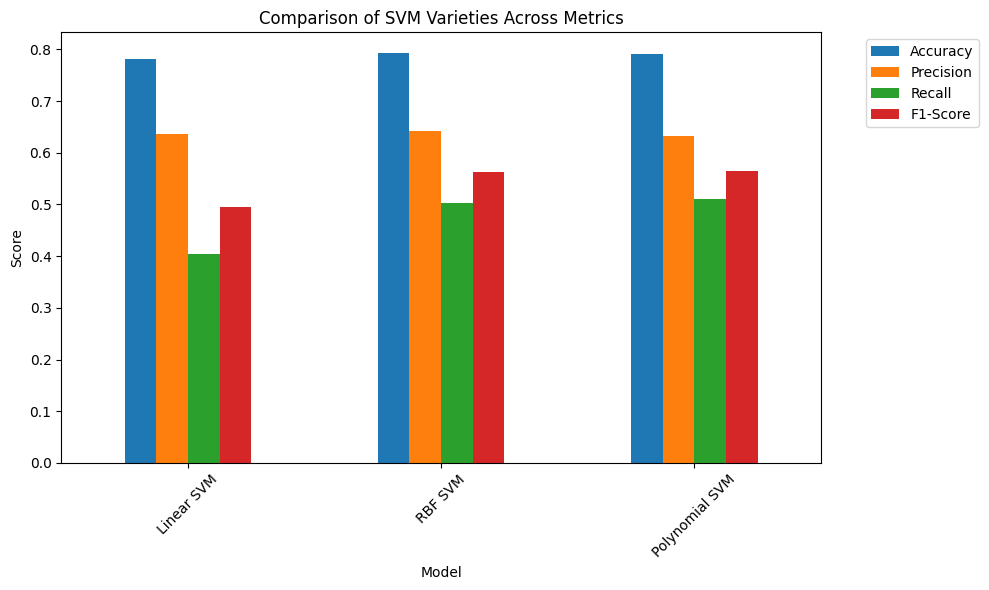

In [27]:
#visualization
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
comparison_df.set_index('Model')[metrics_to_plot].plot(kind='bar', figsize=(10,6))
plt.title('Comparison of SVM Varieties Across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()